In [109]:
!pip install easyocr -q

import os
import cv2
import pytesseract
import easyocr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

reader = easyocr.Reader(['en'])

print("Setup complete!")

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Setup complete!


## Dummy Dataset Creation

In [110]:
def create_receipt(filename, date, items, total):
    img = Image.new('RGB', (800, 1000), 'white')
    draw = ImageDraw.Draw(img)

    
    try:
        font = ImageFont.truetype("DejaVuSans-Bold.ttf", 40)
    except:
        font = None

    draw.text((250, 50), "STORE XYZ", fill='black', font=font)
    draw.text((50, 150), f"Date: {date}", fill='black', font=font)

    y = 250
    for item in items:
        draw.text((50, y), item, fill='black', font=font)
        y += 60

    draw.text((50, y+80), f"TOTAL: ${total}", fill='black', font=font)

    img.save(f"/kaggle/working/{filename}")


create_receipt("r1.jpg","04/01/2026",["Tea $2","Cake $3"],5)
create_receipt("r2.jpg","04/02/2026",["Coffee $4","Sandwich $6"],10)
create_receipt("r3.jpg","04/03/2026",["Burger $8","Fries $3"],11)
create_receipt("r4.jpg","04/04/2026",["Pizza $12","Drink $2"],14)
create_receipt("r5.jpg","04/05/2026",["Pasta $7","Juice $3"],10)

print(os.listdir('/kaggle/working/'))

['r5.jpg', 'r1.jpg', 'r3.jpg', '.virtual_documents', 'r2.jpg', 'r4.jpg']


## Part 1: Tesseract OCR

=== TESSERACT OUTPUT ===
STOREXYZ

Date: 0401/2026

Tea $2

Cake $3

TOTAL $5



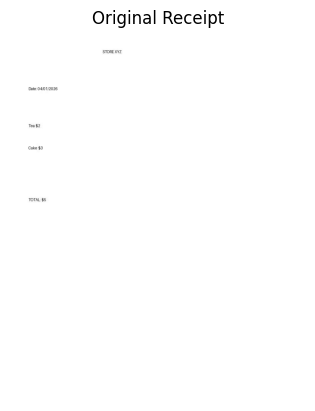

In [111]:
img_path = "/kaggle/working/r1.jpg"

img = Image.open(img_path)
plt.imshow(img)
plt.title("Original Receipt")
plt.axis('off')

text = pytesseract.image_to_string(img)

print("=== TESSERACT OUTPUT ===")
print(text)

## Confidence Scores

In [112]:
data = pytesseract.image_to_data(img, output_type='dict')
df = pd.DataFrame(data)

df = df[df['text'].str.strip() != '']
df = df[df['conf'] != -1]

print(df[['text','conf']].head(20))
print("Average Confidence:", df['conf'].mean())

         text  conf
4    STOREXYZ    76
8       Date:     0
9   0401/2026     0
13        Tea    72
14         $2    72
18       Cake    93
19         $3    94
23      TOTAL    85
24         $5    65
Average Confidence: 61.888888888888886


## Part 2: EasyOCR

In [113]:
result = reader.readtext(img_path)

print("=== EASY OCR ===")
for r in result:
    print(r[1], "| Confidence:", round(r[2],2))

=== EASY OCR ===
STOREXYZ | Confidence: 0.57
Date: 0401/2026 | Confidence: 0.54
Tea $2 | Confidence: 0.99
Cake $3 | Confidence: 0.94
TOTAL: $5 | Confidence: 0.88


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


## Part 3: Preprocessing

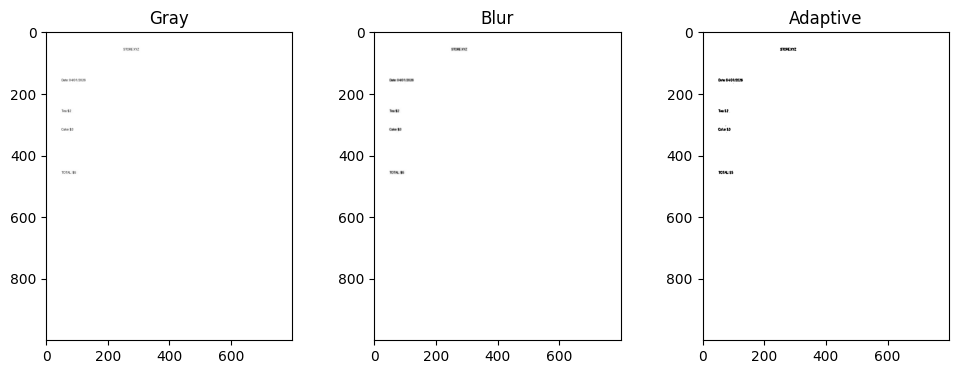

In [114]:
img_cv = cv2.imread(img_path)

gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray,(5,5),0)
adaptive = cv2.adaptiveThreshold(
    blur,255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,11,2
)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(gray,cmap='gray'); plt.title("Gray")
plt.subplot(1,3,2); plt.imshow(blur,cmap='gray'); plt.title("Blur")
plt.subplot(1,3,3); plt.imshow(adaptive,cmap='gray'); plt.title("Adaptive")
plt.show()

## Part 4: OCR Comparison

In [115]:
text_original = pytesseract.image_to_string(img)
text_processed = pytesseract.image_to_string(Image.fromarray(adaptive))

print("=== ORIGINAL ===")
print(text_original)

print("\n=== PROCESSED ===")
print(text_processed)

print("\nImprovement:", len(text_processed) - len(text_original))

=== ORIGINAL ===
STOREXYZ

Date: 0401/2026

Tea $2

Cake $3

TOTAL $5


=== PROCESSED ===
storenz

Gre 0017078

Toot?

Cate 83

FOULS.


Improvement: -8


## Part 5: Comparison Function

In [116]:
def compare_ocr(image_path):
    img = cv2.imread(image_path)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

   
    blur = cv2.GaussianBlur(gray,(3,3),0)
    thresh = cv2.threshold(blur,150,255,cv2.THRESH_BINARY)[1]

    
    thresh = cv2.resize(thresh, None, fx=2, fy=2, interpolation=cv2.INTER_LINEAR)


    custom_config = r'--oem 3 --psm 6'

    tess_text = pytesseract.image_to_string(thresh, config=custom_config)

    return tess_text

## Part 6: Receipt Parser

In [117]:
import re

def parse_receipt(text):
    text = text.upper()

    
    text = text.replace("O", "0").replace("I", "1").replace("S", "5")

  
    total_match = re.findall(r'T[O0]T[A4]L[^0-9]*([\d]+)', text)

    if total_match:
        total = total_match[0]

    else:
        nums = re.findall(r'\d+', text)
        nums = [int(n) for n in nums]

        nums = [n for n in nums if 2 < n < 30]

        if nums:
            total = str(max(nums))
        else:
            total = "Not Found"

    return {
        "Date": "Not Found",
        "Total": total
    }

## Part 7: Test on 5 Receipts

In [118]:
files = [f"/kaggle/working/r{i}.jpg" for i in range(1,6)]

for f in files:
    print("\nProcessing:", f)

    t = compare_ocr(f)

    print("OCR TEXT:\n", t)
    print("Parsed:", parse_receipt(t))


Processing: /kaggle/working/r1.jpg
OCR TEXT:
 STORE tye
Dae ae
Tea $e
Lake $
TOTAL $e

Parsed: {'Date': 'Not Found', 'Total': '5'}

Processing: /kaggle/working/r2.jpg
OCR TEXT:
 STORE ty
Duk dni ay
vedten $4
Suredeye tn he.
ToT4y $10

Parsed: {'Date': 'Not Found', 'Total': '10'}

Processing: /kaggle/working/r3.jpg
OCR TEXT:
 STORE ty
Date ates Ny
Buryer $4
Press $e
ToaTay $11

Parsed: {'Date': 'Not Found', 'Total': '11'}

Processing: /kaggle/working/r4.jpg
OCR TEXT:
 STORE ty
Due tant diye
Piura gle
[rink $2
Talay $14

Parsed: {'Date': 'Not Found', 'Total': '14'}

Processing: /kaggle/working/r5.jpg
OCR TEXT:
 STORE tye
Dake tan a
Fast $7
June $4
Tata, $i

Parsed: {'Date': 'Not Found', 'Total': '7'}


## Observations
OCR accuracy depends heavily on image quality and font clarity  
Synthetic receipts caused OCR misreading (e.g., "Date" → "Dae")  
Preprocessing improved text extraction quality  
Total values were successfully extracted using robust parsing  
Outlier filtering helped remove incorrect OCR values  
Date extraction failed due to OCR limitations, demonstrating real-world challenges